In [26]:
# Modules de base
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Module relatif à Gurobi
from gurobipy import *

# Get and process files

In [27]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import re
from typing import Any, Dict, List, Tuple, Optional, Union


# ----------------------------
# 1) File locator (decoupled)
# ----------------------------

def _format_density(density: Union[int, float, str]) -> str:
    """
    Convert density to the exact string used in folder/file names.
    Examples:
      1    -> "1"
      0.9  -> "0.9"
      0.95 -> "0.95"
      "4"  -> "4"
    """
    if isinstance(density, str):
        s = density.strip()
        # Normalize "1.0" -> "1" etc.
        try:
            f = float(s)
            if f.is_integer():
                return str(int(f))
            return s.rstrip("0").rstrip(".") if "." in s else s
        except ValueError:
            return s

    if isinstance(density, (int, float)):
        f = float(density)
        if f.is_integer():
            return str(int(f))
        # keep minimal representation (0.90 -> 0.9)
        s = repr(f)
        return s.rstrip("0").rstrip(".")
    return str(density)


def find_dat_file(
    base_dir: Union[str, Path],
    density: Union[int, float, str],
    p: int,
    h: int,
    test: Optional[int] = None,
    *,
    top_folders: Tuple[str, str] = ("Data", "Data with maintenance constraints"),
    folder_prefix: str = "d=",
    file_prefix: str = "DataCplex_",
) -> Path:
    """
    Search for the .dat matching density/p/h/(optional)test under:
      base_dir/Data/d=<density>/
      base_dir/Data with maintenance constraints/d=<density>/
    Returns the Path if uniquely found, otherwise raises an error.
    """
    base_dir = Path(base_dir)
    d_str = _format_density(density)

    candidates: List[Path] = []

    # Search both top folders (works even if one doesn't exist)
    for top in top_folders:
        d_folder = base_dir / top / f"{folder_prefix}{d_str}"
        if not d_folder.exists():
            continue

        if test is None:
            pattern = f"{file_prefix}density={d_str}_p={p}_h={h}_test_*.dat"
        else:
            pattern = f"{file_prefix}density={d_str}_p={p}_h={h}_test_{test}.dat"

        candidates.extend(sorted(d_folder.glob(pattern)))

    if not candidates:
        raise FileNotFoundError(
            f"No .dat file found for density={d_str}, p={p}, h={h}, test={test} under {base_dir}"
        )

    # If test=None we might match multiple; require uniqueness to be safe
    if len(candidates) > 1:
        msg = "\n".join(str(c) for c in candidates[:30])
        more = "" if len(candidates) <= 30 else f"\n... and {len(candidates)-30} more"
        raise FileExistsError(
            f"Multiple matching .dat files found for density={d_str}, p={p}, h={h}, test={test}:\n{msg}{more}\n"
            f"Pass test=<n> to select a unique file."
        )

    return candidates[0]


# ----------------------------
# 2) Parser (decoupled)
# ----------------------------

_DECL_RE = re.compile(r"(?ms)^\s*(\w+)\s*=\s*(.*?)\s*;\s*$")

def _parse_atom(token: str) -> Union[int, float, str]:
    token = token.strip()
    if token == "":
        return token

    # Try int then float
    try:
        if re.fullmatch(r"[+-]?\d+", token):
            return int(token)
        if re.fullmatch(r"[+-]?\d*\.\d+(?:[eE][+-]?\d+)?", token) or re.fullmatch(r"[+-]?\d+(?:[eE][+-]?\d+)", token):
            return float(token)
    except ValueError:
        pass

    # Otherwise string (e.g., airport codes A,B,C)
    return token


def _parse_set(value: str) -> List[Union[int, float, str]]:
    # value like "{A,B,C,}" or "{0,1,2,}"
    inner = value.strip()[1:-1].strip()
    if inner == "":
        return []
    parts = [p.strip() for p in inner.split(",")]
    parts = [p for p in parts if p != ""]
    return [_parse_atom(p) for p in parts]


def _parse_tuples_from_angle_brackets(value: str) -> List[Tuple[Union[int, float, str], ...]]:
    # Extract all <...> blocks, split by commas inside
    tuples: List[Tuple[Union[int, float, str], ...]] = []
    for body in re.findall(r"<([^<>]*)>", value, flags=re.S):
        fields = [f.strip() for f in body.split(",")]
        fields = [f for f in fields if f != ""]
        tuples.append(tuple(_parse_atom(f) for f in fields))
    return tuples


def _parse_matrix(value: str) -> List[List[Union[int, float]]]:
    """
    Parses something like:
      Cost =[
        [6804.0,6870.0,...,]
        [4536.0,4580.0,...,]
      ];
    Note: rows are NOT comma-separated in your file, so we scan bracket depth.
    """
    s = value.strip()
    if not (s.startswith("[") and s.endswith("]")):
        raise ValueError("Matrix must start with '[' and end with ']'")

    content = s[1:-1].strip()

    rows: List[str] = []
    i = 0
    n = len(content)
    while i < n:
        # Find next row '['
        while i < n and content[i].isspace():
            i += 1
        if i >= n:
            break
        if content[i] != "[":
            # skip unexpected chars
            i += 1
            continue

        # parse one row [...]
        depth = 0
        start = i
        while i < n:
            ch = content[i]
            if ch == "[":
                depth += 1
            elif ch == "]":
                depth -= 1
                if depth == 0:
                    end = i
                    rows.append(content[start + 1 : end])  # inside [...]
                    i += 1
                    break
            i += 1

    matrix: List[List[Union[int, float]]] = []
    for row in rows:
        nums = [x.strip() for x in row.replace("\n", " ").split(",")]
        nums = [x for x in nums if x != ""]
        parsed_row: List[Union[int, float]] = []
        for x in nums:
            atom = _parse_atom(x)
            if isinstance(atom, str):
                raise ValueError(f"Non-numeric value in matrix: {atom!r}")
            parsed_row.append(atom)
        matrix.append(parsed_row)

    return matrix


def parse_dat_file(dat_path: Union[str, Path]) -> Dict[str, Any]:
    """
    Parses an OPL/CPLEX-like .dat into a dict:
      - Sets {...} -> Python list
      - Scalars -> int/float/str
      - Tuple lists <...> -> list[tuple]
      - Matrices [...] with row brackets -> list[list[float/int]]
    """
    dat_path = Path(dat_path)
    text = dat_path.read_text(encoding="utf-8", errors="replace")

    out: Dict[str, Any] = {}

    # Split by semicolons safely by matching "name = ... ;" blocks (multiline)
    for m in _DECL_RE.finditer(text):
        name = m.group(1)
        raw = m.group(2).strip()

        if raw.startswith("{") and raw.endswith("}"):
            # could be a set, or a tuple-set like Flight = { <...> <...> }
            if "<" in raw and ">" in raw:
                out[name] = _parse_tuples_from_angle_brackets(raw)
            else:
                out[name] = _parse_set(raw)

        elif raw.startswith("[") and raw.endswith("]"):
            # could be matrix, or list of tuples inside brackets
            if "<" in raw and ">" in raw:
                out[name] = _parse_tuples_from_angle_brackets(raw)
            else:
                out[name] = _parse_matrix(raw)

        else:
            # scalar
            out[name] = _parse_atom(raw)

    return out



In [28]:
base = Path.cwd()  # or Path(__file__).resolve().parent

# Find file by params:
dat_file = find_dat_file(base, density=0.9, p=10, h=7, test=0)
# dat_file = "/home/hyper/CentraleSupélec/Transport Passagers/Air France/test.dat"    # --- TEST ---

data = parse_dat_file(dat_file)

print("Keys:", data.keys())
print("Nbflight:", data["Nbflight"])
print("First Flight tuple:", data["Flight"][0])
print("Cost shape:", len(data["Cost"]), "x", len(data["Cost"][0]) if data["Cost"] else 0)
print("First Aircraft tuple:", data["Aircraft"][0])

Airports   = data["Airports"]   # list of airport codes
Nbflight   = data["Nbflight"]   # number of flights
Aircrafts  = data["Aircrafts"]  # list of aircraft ids
Flight     = data["Flight"]     # list of tuples (flight_id, origin, destination, departure_time, arrival_time)
Cost       = data["Cost"]       # list of lists: Cost[j][t] = cost of flight j with aircraft k
Aircraft   = data["Aircraft"]   # tuple of initial position (aircraft, airport)

# Flight_id starts on 1
# Aircraft_id starts on 0

Keys: dict_keys(['Airports', 'Nbflight', 'Aircrafts', 'Flight', 'Cost', 'Aircraft'])
Nbflight: 167
First Flight tuple: (1, 'MAD', 'HAM', 6360.0, 6615.0)
Cost shape: 167 x 10
First Aircraft tuple: (0, 'HAM')


# Modeling

In [29]:
# --- 1. SETUP & PARAMETERS ---
# Assuming these variables exist from your previous cells:
# Flight: List of (id, origin, dest, dep, arr)
# Aircraft: List of (id, initial_pos)
# Cost: Matrix where Cost[i][k] is cost for flight i+1, aircraft k

MIN_TURN_TIME = 0  # Minimum ground time in minutes

# Create handy lookup dictionaries for speed
# flight_dict: ID -> {origin, dest, dep, arr}
flight_dict = {
    int(f[0]): {"org": f[1], "dst": f[2], "dep": f[3], "arr": f[4]} 
    for f in Flight
}
all_flight_ids = list(flight_dict.keys())

# aircraft_dict: ID -> initial_pos
aircraft_dict = {
    int(a[0]): a[1] 
    for a in Aircraft
}
all_aircraft_ids = list(aircraft_dict.keys())

# --- 2. PRE-PROCESSING (FEASIBILITY MATRIX) ---
# We build the sparse set of valid connections to avoid creating N*N*K variables.

feasible_arcs = []   # List of valid (flight_i_id, flight_j_id)
valid_starts = []    # List of valid (aircraft_id, flight_j_id)

# A. Flight-to-Flight Connections
for i_id in all_flight_ids:
    for j_id in all_flight_ids:
        if i_id == j_id: continue
        
        f_i = flight_dict[i_id]
        f_j = flight_dict[j_id]
        
        # Check C3: Equipment Continuity (ArrAirport_i == DepAirport_j)
        if f_i["dst"] != f_j["org"]:
            continue
            
        # Check C1: Turn Time (DepTime_j >= ArrTime_i + Gap)
        if f_j["dep"] < f_i["arr"] + MIN_TURN_TIME:
            continue
            
        feasible_arcs.append((i_id, j_id))

# B. Start-to-Flight Connections (Initial Positions)
for k_id, start_pos in aircraft_dict.items():
    for j_id in all_flight_ids:
        f_j = flight_dict[j_id]
        
        # Check C2: Initial Position (Aircraft start == Flight origin)
        if start_pos == f_j["org"]:
            valid_starts.append((k_id, j_id))

print(f"Generated {len(feasible_arcs)} feasible flight connections.")
print(f"Generated {len(valid_starts)} feasible start connections.")

# --- 3. OPTIMIZATION MODEL ---

m = Model("TailAssignment_Heavy")
m.params.OutputFlag = 0  # Suppress solver output for cleaner display

# --- Decision Variables ---
x = {}      # x[i, j, k]: Flight i -> Flight j on Aircraft k
x_start = {} # x_start[k, j]: Start -> Flight j on Aircraft k
x_end = {}   # x_end[i, k]: Flight i -> End on Aircraft k

# 3.1 Flight-to-Flight Variables
for (i, j) in feasible_arcs:
    for k in all_aircraft_ids:
        # Cost is usually associated with the assignment of flight j
        # Adjust index: Flight IDs are 1-based, Matrix is 0-based
        c = Cost[j - 1][k]
        x[i, j, k] = m.addVar(vtype=GRB.BINARY, obj=c, name=f"x_{i}_{j}_{k}")

# 3.2 Start Variables
for (k, j) in valid_starts:
    c = Cost[j - 1][k]
    x_start[k, j] = m.addVar(vtype=GRB.BINARY, obj=c, name=f"Start_{k}_{j}")

# 3.3 End Variables (Sink)
for i in all_flight_ids:
    for k in all_aircraft_ids:
        x_end[i, k] = m.addVar(vtype=GRB.BINARY, obj=0, name=f"End_{i}_{k}")

m.update()

# --- Constraints ---

# 1. Coverage: Every flight j must have exactly one incoming connection
for j in all_flight_ids:
    # Incoming from other flights + Incoming from Start
    incoming_flights = quicksum(x[i, j, k] for i, curr, k in x if curr == j)
    incoming_starts = quicksum(x_start[k, curr] for k, curr in x_start if curr == j)
    
    m.addConstr(incoming_flights + incoming_starts == 1, name=f"Cover_{j}")

# 2. Flow Conservation: For every flight j and aircraft k, Flow In == Flow Out
for k in all_aircraft_ids:
    for j in all_flight_ids:
        # Flow IN: From other flights (i->j) OR from Start (Start->j)
        flow_in = quicksum(x[i, curr, plane] for i, curr, plane in x 
                              if curr == j and plane == k)
        flow_in += quicksum(x_start[plane, curr] for plane, curr in x_start 
                               if curr == j and plane == k)
        
        # Flow OUT: To other flights (j->l) OR to End (j->End)
        flow_out = quicksum(x[prev, l, plane] for prev, l, plane in x 
                               if prev == j and plane == k)
        flow_out += x_end[j, k]
        
        m.addConstr(flow_in == flow_out, name=f"Flow_{j}_{k}")

# 3. Aircraft Usage: Each aircraft must start exactly once
# (Note: If some aircraft can remain unused, change '== 1' to '<= 1')
for k in all_aircraft_ids:
    m.addConstr(quicksum(x_start[plane, j] for plane, j in x_start if plane == k) <= 1, 
                name=f"UsePlane_{k}")

# --- Solve ---
m.optimize()

Generated 1389 feasible flight connections.
Generated 221 feasible start connections.


# PRINTS

In [30]:
if m.status == GRB.OPTIMAL:
    print("\n" + "="*40)
    print(f"--- OPTIMAL SCHEDULE FOUND ---")
    print(f"Total Operational Cost: {m.objVal:,.2f}")
    print("="*40)
    
    # # Iterate through every aircraft to trace its route
    # for k_id in all_aircraft_ids:
    #     start_airport = aircraft_dict[k_id]
    #     print(f"\nAircraft {k_id} (Initial Base: {start_airport}):")
        
    #     route = []
    #     current_flight_id = None
        
    #     # 1. Find the FIRST flight (Start -> Flight j)
    #     for (plane, j_id), var in x_start.items():
    #         if plane == k_id and var.x > 0.5:
    #             current_flight_id = j_id
    #             break
        
    #     # If no start found, the aircraft was not used
    #     if current_flight_id is None:
    #         print("   [UNUSED]")
    #         continue
            
    #     # 2. Trace the CHAIN (Flight i -> Flight j)
    #     while True:
    #         # Add current flight to the route list
    #         f_info = flight_dict[current_flight_id]
    #         route.append(f"F{current_flight_id}[{f_info['org']}->{f_info['dst']}]")
            
    #         next_flight_id = None
            
    #         # Check Flight-to-Flight connections for the next hop
    #         for (i, j, plane), var in x.items():
    #             if plane == k_id and i == current_flight_id and var.x > 0.5:
    #                 next_flight_id = j
    #                 break
            
    #         # If no next flight found, it means the aircraft goes to 'End'
    #         if next_flight_id is None:
    #             break
            
    #         # Move to the next flight in the chain
    #         current_flight_id = next_flight_id
        
    #     # Print the formatted route
    #     print("   " + " -> ".join(route))

elif m.status == GRB.INFEASIBLE:
    print("\nNo solution found (INFEASIBLE).")
    print("Computing IIS to find the exact conflicting constraints...")
    
    # This will calculate the conflict and write it to a file
    m.computeIIS()
    m.write("conflict_model.ilp")
    
    print("\nCheck the 'conflict_model.ilp' file generated in your folder.")
    print("It will show you exactly which flights/aircraft rules are impossible to satisfy together.")
    
else:
    print(f"\nSolver finished with status code: {m.status}")


--- OPTIMAL SCHEDULE FOUND ---
Total Operational Cost: 1,349,297.00


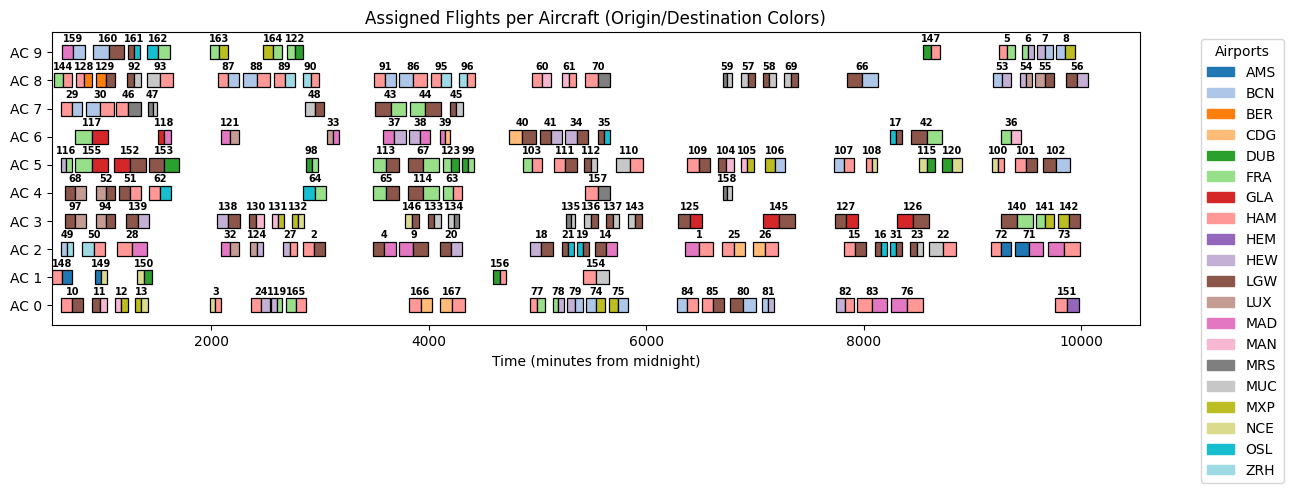

In [31]:
# --------- Build assigned flights (trace routes for 3-index model) ----------
assigned = {k: [] for k in all_aircraft_ids}
airports = set()

# Iterate through every aircraft to trace its assigned route
for k_id in all_aircraft_ids:
    current_flight_id = None
    
    # 1. Find the FIRST flight (Start -> Flight j)
    for (plane, j_id), var in x_start.items():
        if plane == k_id and var.x > 0.5:
            current_flight_id = j_id
            break
            
    # If no start found, the aircraft was not used
    if current_flight_id is None:
        continue
        
    # 2. Trace the CHAIN (Flight i -> Flight j)
    while True:
        # Extract flight info from our dictionary
        f_info = flight_dict[current_flight_id]
        dep = f_info["dep"]
        arr = f_info["arr"]
        fid = current_flight_id
        org = f_info["org"]
        dst = f_info["dst"]
        
        # Append to the aircraft's assigned list
        assigned[k_id].append((dep, arr, fid, org, dst))
        
        # Add airports to the set for coloring
        airports.add(org)
        airports.add(dst)
        
        # Find the NEXT flight (j -> next)
        next_flight_id = None
        for (i, j, plane), var in x.items():
            if plane == k_id and i == current_flight_id and var.x > 0.5:
                next_flight_id = j
                break
        
        # If no next flight found, the route ends
        if next_flight_id is None:
            break
            
        # Move to next hop
        current_flight_id = next_flight_id

# --------- Assign one color per airport ----------
airports = sorted(list(airports))
cmap = plt.get_cmap("tab20", len(airports))
airport_color = {ap: cmap(idx) for idx, ap in enumerate(airports)}

# --------- Plot ----------
row_spacing = 1.4   # increase spacing between aircraft rows
bar_height  = 0.7   # slightly taller bars

# Count used aircraft to set figure height properly
used_aircraft = sum(1 for k in all_aircraft_ids if assigned[k])
fig, ax = plt.subplots(figsize=(13, max(2, 0.45 * used_aircraft)))

y = 0
yticks = []
ylabels = []

for k_id in all_aircraft_ids:
    # Skip plotting if the aircraft has no assigned flights
    if not assigned[k_id]:
        continue

    yticks.append(y)
    # Use the original aircraft ID
    ylabels.append(f"AC {k_id}")

    for (dep, arr, fid, origin, dest) in assigned[k_id]:
        duration = arr - dep
        mid = dep + duration / 2.0

        # left half = origin color
        ax.barh(
            y, mid - dep, left=dep, height=bar_height,
            color=airport_color[origin],
            edgecolor="black", linewidth=0.9
        )

        # right half = destination color
        ax.barh(
            y, arr - mid, left=mid, height=bar_height,
            color=airport_color[dest],
            edgecolor="black", linewidth=0.9
        )

        # flight ID ABOVE the block (centered)
        ax.text(
            dep + duration/2,
            y + bar_height/2 + 0.08,
            str(fid),
            ha="center",
            va="bottom",
            fontsize=7,
            fontweight="bold"
        )

    y += row_spacing

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_xlabel("Time (minutes from midnight)")
ax.set_title("Assigned Flights per Aircraft (Origin/Destination Colors)")

# Add a legend for the airports
handles = [plt.Rectangle((0,0),1,1, color=airport_color[ap]) for ap in airports]
ax.legend(handles, airports, title="Airports", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# TODO
gurobi ilp file resolve conflict

m.write()

compare feasability matrix